<a href="https://colab.research.google.com/github/Gpxmenon/Gpxmenon.github.io/blob/master/Comparison_between_the_metasediment_and_abiotic_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install spectrochempy BaselineRemoval lmfit seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.2 MB/s eta 0:00:00


In [14]:
%matplotlib inline

In [6]:
from google.colab import files
print("Upload your raman_thermometry.zip now")
uploaded = files.upload()

Upload your raman_thermometry.zip now


Saving raman_thermometry.zip to raman_thermometry.zip


In [7]:
import os, sys

# Unzip
os.makedirs("raman_pkg", exist_ok=True)
os.system("unzip -o raman_thermometry.zip -d raman_pkg")

# Find where pyproject.toml is
for root, dirs, fs in os.walk("raman_pkg"):
    if "pyproject.toml" in fs:
        print("Found package at:", root)
        os.system(f"pip install '{root}' -q")
        break

Found package at: raman_pkg/raman_thermometry


In [9]:
from google.colab import files
print("Upload your two CSV files now")
uploaded_data = files.upload()
print("Uploaded:", list(uploaded_data.keys()))

Upload your two CSV files now


Saving 260429.csv to 260429 (1).csv
Saving COMBINED.csv to COMBINED.csv
Uploaded: ['260429 (1).csv', 'COMBINED.csv']


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from raman_thermometry import (
    spectral_preprocessing,
    analyze_raman_peaks,
    calculate_skewness,
    calculate_spectral_parameters,
    calculate_temp,
)

# ── EDIT THESE TWO LINES if your filenames are different ──
ABIOTIC_FILE      = "260429.csv"
METASEDIMENT_FILE = "COMBINED.csv"

# Load abiotic (two X-column blocks)
raw_ab  = pd.read_csv(ABIOTIC_FILE)
cols_ab = list(raw_ab.columns)
x_pos   = [i for i, c in enumerate(cols_ab) if 'X value' in c]
block1  = raw_ab.iloc[:, :x_pos[1]].copy()
block2  = raw_ab.iloc[:, x_pos[1]:].copy()
block1.rename(columns={block1.columns[0]: 'X value [cm⁻¹]'}, inplace=True)
block2.rename(columns={block2.columns[0]: 'X value [cm⁻¹]'}, inplace=True)
df_ab = block1.copy()
for col in block2.columns:
    if col != 'X value [cm⁻¹]':
        df_ab[col] = block2[col].values
print(f"Abiotic: {df_ab.shape[1]-1} spectra loaded")

# Load metasediment (single X column)
raw_ms = pd.read_csv(METASEDIMENT_FILE)
df_ms  = raw_ms.rename(columns={raw_ms.columns[0]: 'X value [cm⁻¹]'})
print(f"Metasediment: {df_ms.shape[1]-1} spectra loaded")

# Preprocess
print("Preprocessing... (takes ~1 min)")
proc_ab = spectral_preprocessing(df_ab.copy())
proc_ms = spectral_preprocessing(df_ms.copy())
print("Done")

# Peak definitions
peak_names   = ['D',         'G',         'D2',        '2D1',       '2D2'      ]
peak_centers = [1350,        1580,        1620,        2675,        2720       ]
peak_ranges  = [(1300,1400), (1520,1610), (1615,1630), (2650,2700), (2700,2740)]

# Fit peaks
print("Fitting peaks... (takes 1-2 min)")
dec_ab = analyze_raman_peaks(proc_ab.select_dtypes(include='number'), peak_names, peak_centers, peak_ranges)
dec_ms = analyze_raman_peaks(proc_ms.select_dtypes(include='number'), peak_names, peak_centers, peak_ranges)

# Skewness
skew_ab = calculate_skewness(proc_ab.select_dtypes(include='number'), '2D', (2650,2750))
skew_ms = calculate_skewness(proc_ms.select_dtypes(include='number'), '2D', (2650,2750))
dec_ab  = pd.concat([dec_ab, skew_ab], axis=1)
dec_ms  = pd.concat([dec_ms, skew_ms], axis=1)

# Parameters and temperatures
dec_ab = calculate_spectral_parameters(dec_ab)
dec_ms = calculate_spectral_parameters(dec_ms)
for df in [dec_ab, dec_ms]:
    df['T_Beyssac'] = calculate_temp(df.copy(), method='Beyssac')['temp (°C)']
    df['T_Aoya']    = calculate_temp(df.copy(), method='Aoya')['temp (°C)']

print("\n=== ABIOTIC ===")
print(dec_ab[['R1','R2','G_FWHM','T_Beyssac','T_Aoya']].describe().round(2))
print("\n=== METASEDIMENT ===")
print(dec_ms[['R1','R2','G_FWHM','T_Beyssac','T_Aoya']].describe().round(2))

Abiotic: 50 spectra loaded
Metasediment: 29 spectra loaded
Preprocessing... (takes ~1 min)
Done
Fitting peaks... (takes 1-2 min)

=== ABIOTIC ===
          R1     R2  G_FWHM  T_Beyssac  T_Aoya
count  50.00  50.00   50.00      50.00   50.00
mean    0.72   0.33   52.45     493.27  486.92
std     0.31   0.09   31.64      40.24   44.57
min     0.25   0.09   28.55     414.50  405.28
25%     0.47   0.26   31.91     461.31  451.08
50%     0.68   0.33   38.95     495.99  488.16
75%     0.93   0.40   65.52     524.52  520.68
max     1.57   0.51  201.43     603.14  619.70

=== METASEDIMENT ===
          R1     R2  G_FWHM  T_Beyssac  T_Aoya
count  29.00  29.00   29.00      29.00   29.00
mean    0.58   0.30   31.17     506.24  500.74
std     0.26   0.07    7.49      32.05   35.89
min     0.28   0.20   26.40     437.16  426.83
25%     0.35   0.23   28.15     481.20  472.01
50%     0.49   0.30   29.22     508.02  501.65
75%     0.72   0.36   30.27     536.95  535.42
max     1.19   0.46   67.31     5

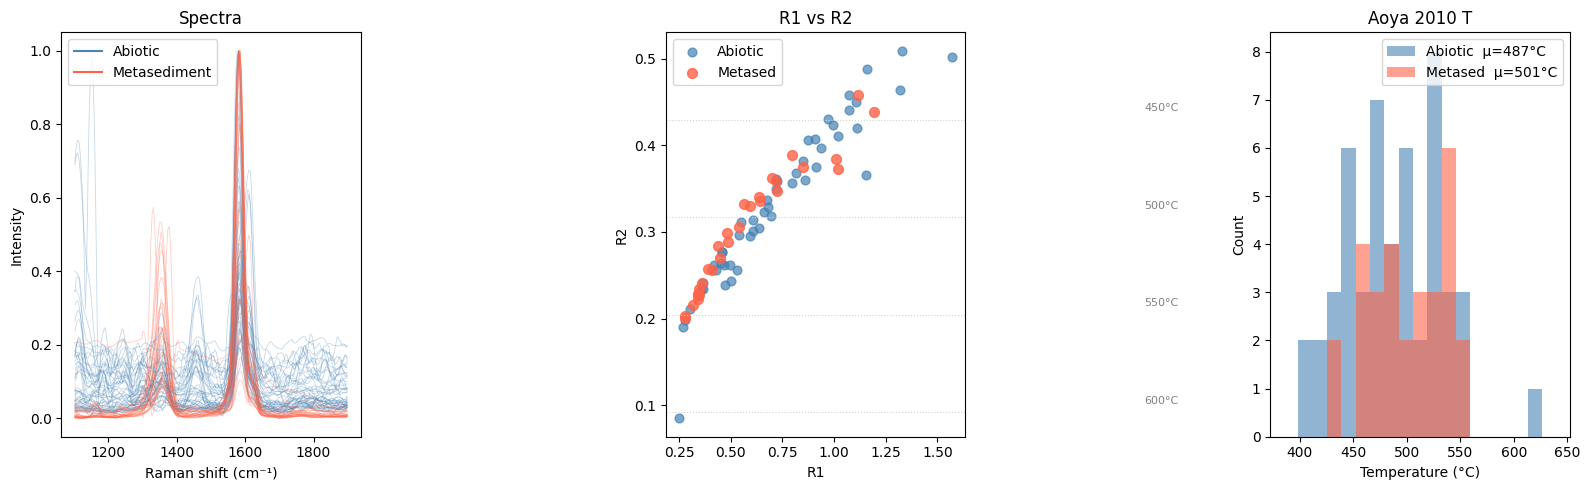

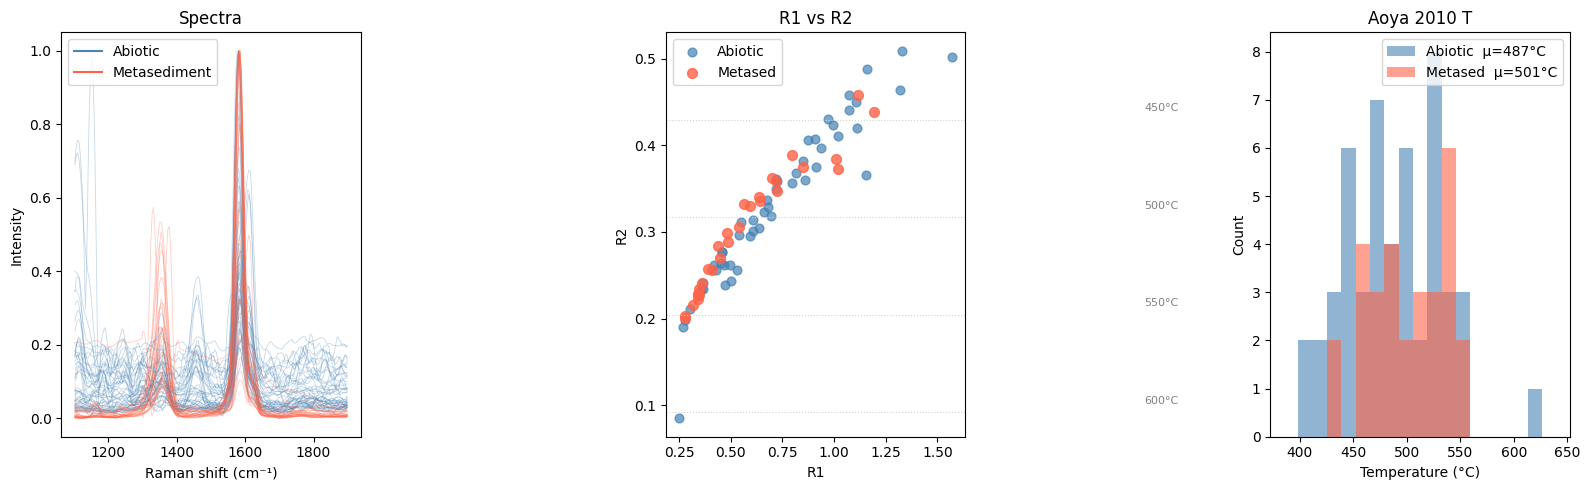

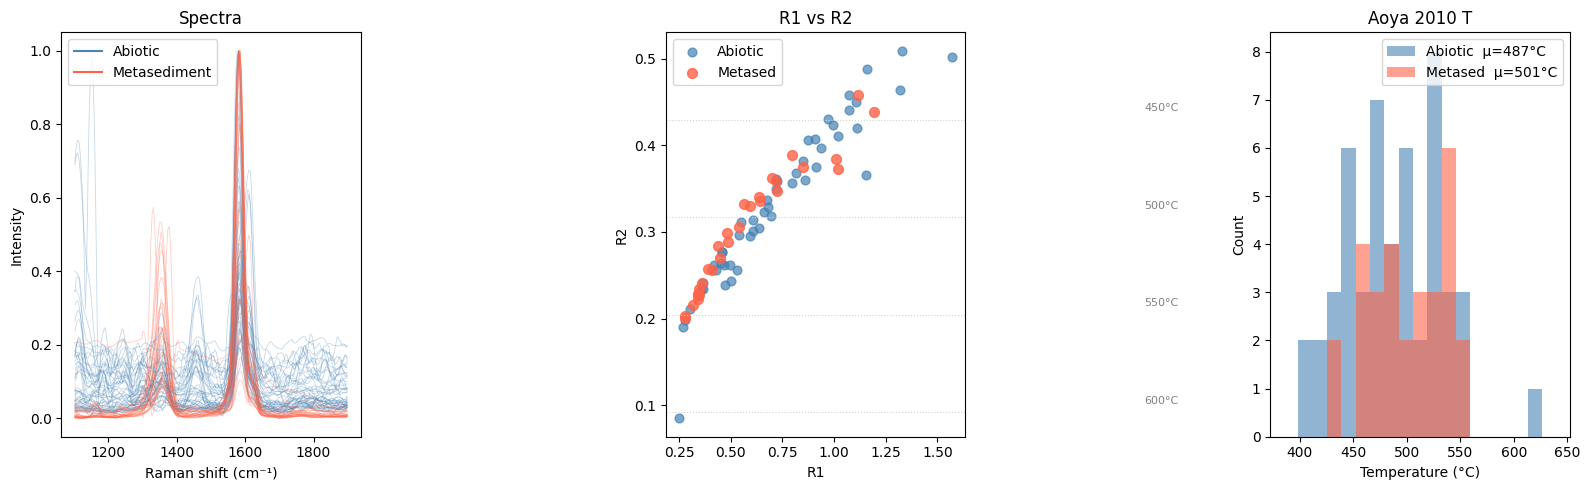

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Spectra
ax = axes[0]
x_vals = proc_ms.columns.astype(float).values
mask = (x_vals >= 1100) & (x_vals <= 1900)
for i, row in proc_ab.iterrows():
    ax.plot(x_vals[mask], row.values[mask], color='steelblue', lw=0.6, alpha=0.3)
for i, row in proc_ms.iterrows():
    ax.plot(x_vals[mask], row.values[mask], color='tomato', lw=0.6, alpha=0.3)
ax.plot([], [], color='steelblue', label='Abiotic')
ax.plot([], [], color='tomato',    label='Metasediment')
ax.set_xlabel('Raman shift (cm⁻¹)'); ax.set_ylabel('Intensity'); ax.set_title('Spectra'); ax.legend()

# R1 vs R2
ax = axes[1]
for T in [450, 500, 550, 600]:
    ax.axhline((641-T)/445, color='lightgrey', lw=0.8, linestyle=':')
    ax.text(2.5, (641-T)/445+0.01, f'{T}°C', fontsize=8, color='grey')
ax.scatter(dec_ab['R1'], dec_ab['R2'], color='steelblue', s=40, alpha=0.7, label='Abiotic')
ax.scatter(dec_ms['R1'], dec_ms['R2'], color='tomato',    s=50, alpha=0.8, label='Metased')
ax.set_xlabel('R1'); ax.set_ylabel('R2'); ax.set_title('R1 vs R2'); ax.legend()

# Temperature
ax = axes[2]
ab_t = dec_ab['T_Aoya'].dropna().values
ms_t = dec_ms['T_Aoya'].dropna().values
bins = np.linspace(min(ab_t.min(), ms_t.min())-20, max(ab_t.max(), ms_t.max())+20, 20)
ax.hist(ab_t, bins=bins, color='steelblue', alpha=0.6, label=f'Abiotic  μ={ab_t.mean():.0f}°C')
ax.hist(ms_t, bins=bins, color='tomato',    alpha=0.6, label=f'Metased  μ={ms_t.mean():.0f}°C')
ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Count'); ax.set_title('Aoya 2010 T'); ax.legend()

plt.tight_layout()
plt.show()

In [13]:
dec_ab.to_csv('results_abiotic.csv')
dec_ms.to_csv('results_metasediment.csv')

from google.colab import files
files.download('results_abiotic.csv')
files.download('results_metasediment.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>